# CreditLens: Credit Risk Analytics and Default Prediction

**Author:** Panchanand Gupta (PGDM, Finance & Analytics) &nbsp;|&nbsp; **Project type:** Academic portfolio project

---
## Section 1: Project Introduction

### 1.1 The credit-risk problem
A bank that issues credit cards lends money before it knows whether the customer will repay. When a customer fails to pay on time, the bank can lose money. Credit-risk analytics tries to estimate, *from past behaviour*, how likely a customer is to default so that the bank can set credit limits, prioritise collections and monitor its portfolio.

### 1.2 Why predicting default matters
- **Provisioning and capital:** lenders must hold reserves against expected losses, and these depend on how many customers are likely to default.
- **Limit management and monitoring:** early warning signs let a risk team review exposure before losses happen.
- **Collections prioritisation:** limited collection effort can be directed at the accounts that are most likely to become delinquent.

### 1.3 Business objective and analytical questions
**Objective:** analyse historical credit-card customer data, understand repayment patterns and default risk, compare predictive models, and communicate what the findings mean for risk analytics.

Questions this notebook answers:
1. How common is default in this portfolio, and how imbalanced is the target?
2. Which customer characteristics and repayment behaviours are associated with default?
3. How well can classical Machine Learning models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) separate defaulters from non-defaulters?
4. Does a simple feed-forward neural network (Deep Learning) add anything over these models?
5. Which variables matter most to the preferred model, and what can (and cannot) be concluded from that?

### 1.4 Dataset and citation
Dataset: **Default of Credit Card Clients**, UCI Machine Learning Repository
(https://archive.ics.uci.edu/dataset/350/default%2Bof%2Bcredit%2Bcard%2Bclients).
It contains 30,000 credit-card customers from a bank in Taiwan, with a six-month payment history (April to September 2005). The dataset is described in:

> Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473-2480.

### 1.5 Target variable
The target is the column **`default payment next month`** (verified from the file in Section 3):
- `1` = the customer **defaulted** in the following month (positive class)
- `0` = the customer did **not** default

A positive model prediction therefore means *"the model flags this customer as likely to default next month"*.

### 1.6 Limitations of historical data
- The data covers one short period (2005) and one market. Customer behaviour and economic conditions change, so a model trained on this period may not work on another.
- The labels only record default in a single month, not long-term loss.
- Only customers who were *given* a card appear in the data, so we know nothing about applicants who were rejected (selection bias).
- Some codes in the file are undocumented (see Section 5), so some features have uncertain meaning.

> **Important:** this is an educational analytics project. The models here are **not validated or approved for any real lending decision**.

---
## Section 2: Import Libraries

### Techniques reused from my coursework notebook vs. what is new
I first reviewed my Machine Learning coursework notebook. It used `pandas`, `numpy`, `matplotlib`, `seaborn`, `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`, accuracy / precision / recall / F1 / confusion matrix, `GridSearchCV` and `RandomizedSearchCV`.

**Reused here:** all of the above.

**New techniques, introduced only because correct modelling needs them** (each is explained where it first appears):

| New item | Why it is needed |
|---|---|
| `Pipeline` + `ColumnTransformer` + `OneHotEncoder` | Keeps scaling/encoding inside cross-validation so nothing leaks from the validation folds or test set. |
| `StratifiedKFold`, `cross_val_predict` | Gives out-of-fold predictions on the training data, used to pick a classification threshold without touching the test set. |
| ROC-AUC, Average Precision, Brier score, `precision_recall_curve` | Accuracy is misleading when only about 22% of customers default. |
| `permutation_importance` | Model-agnostic way to see which features drive predictions. |
| TensorFlow / Keras | Needed for the Deep Learning (neural network) challenger. |

**Not reused on purpose:** my coursework applied SMOTE. Here I do **not** resample. Resampling distorts predicted probabilities (which I want to evaluate with the Brier score), and the brief for this project asks that resampling not be added just to look advanced. Class imbalance is handled through imbalance-aware metrics and by choosing the decision threshold on training data.

In [1]:
# ---------- Standard libraries ----------
import os
import warnings

# ---------- Data handling and plotting ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- scikit-learn: splitting, preprocessing, models ----------
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ---------- Evaluation ----------
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             brier_score_loss, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance

# ---------- Deep learning (needed only for Section 11) ----------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ---------- Settings ----------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
%matplotlib inline

# One random seed used everywhere so results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

print("pandas", pd.__version__, "| scikit-learn", __import__("sklearn").__version__, "| TensorFlow", tf.__version__)

I0000 00:00:1791507660.633446    1418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791507660.764963    1418 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791507662.207225    1418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


pandas 3.0.5 | scikit-learn 1.9.1 | TensorFlow 2.21.0


---
## Section 3: Load and Inspect the Dataset

The UCI Excel file is known to have an **introductory row above the real column headers** (generic labels `X1 ... X23, Y`). I check the raw rows first instead of assuming, then load with the correct header row.

**Place the file `default of credit card clients.xls` in the same folder as this notebook.** Reading `.xls` files needs the `xlrd` package (`pip install xlrd`).

In [2]:
file_name = "default of credit card clients.xls"

if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"'{file_name}' was not found in {os.getcwd()}. "
        "Please copy the dataset file into the same folder as this notebook and run again.")

# Look at the first 3 raw rows WITHOUT assuming a header
raw_preview = pd.read_excel(file_name, header=None, nrows=3)
print("First three raw rows (first 6 and last 3 columns):")
print(raw_preview.iloc[:, list(range(6)) + [22, 23, 24]])

First three raw rows (first 6 and last 3 columns):
    0          1    2          3         4    5         22        23  \
0  NaN         X1   X2         X3        X4   X5       X22       X23   
1   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_AMT5  PAY_AMT6   
2    1      20000    2          2         1   24         0         0   

                           24  
0                           Y  
1  default payment next month  
2                           1  


Row 0 contains generic labels (`X1`, `X2`, ... `Y`) and row 1 contains the real column names (`ID`, `LIMIT_BAL`, ...). The real header is therefore on the **second row**, so I use `header=1`.

In [3]:
df = pd.read_excel(file_name, header=1)

print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nShape (rows, columns):", df.shape)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0



Last 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1



Shape (rows, columns): (30000, 25)


In [4]:
print("Column names:")
print(list(df.columns))
print()
df.info()

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-n

In [5]:
# Numerical summary of every column
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [6]:
# Missing values and duplicates
print("Total missing values:", df.isnull().sum().sum())
print("Fully duplicated rows (including ID):", df.duplicated().sum())
print("Duplicated rows when ID is ignored:   ", df.drop(columns="ID").duplicated().sum())
print("Is ID unique?", df["ID"].is_unique)

Total missing values: 0
Fully duplicated rows (including ID): 0
Duplicated rows when ID is ignored:    35
Is ID unique? True


In [7]:
# Identify the ID column and target variable, and verify the target coding
target_original_name = "default payment next month"
print("ID column     : ID")
print("Target column :", target_original_name)
print("\nTarget values and counts:")
print(df[target_original_name].value_counts().sort_index())
print("\nDefault rate:", round(df[target_original_name].mean(), 4))

ID column     : ID
Target column : default payment next month

Target values and counts:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Default rate: 0.2212


### Observations from the first inspection
- 30,000 rows and 25 columns: `ID`, 23 predictors and the target. All columns are stored as integers and **there are no missing values**.
- The target `default payment next month` contains only 0 and 1, as expected.
- `ID` is unique, so it identifies a customer but carries no predictive meaning. It will not be used as a feature.
- There are no fully duplicated rows, but a few rows are identical when ID is ignored. I investigate these in Section 5 before deciding what to do.

### Making the column names easier to work with
Two small renames, with **no change to values**:
- `default payment next month` becomes `default` (shorter, no spaces).
- `PAY_0` becomes `PAY_1`. In the UCI file the September 2005 repayment status is called `PAY_0` while the other months are `PAY_2` ... `PAY_6`. Renaming it to `PAY_1` makes the series consistent: `PAY_1` and `BILL_AMT1` and `PAY_AMT1` all refer to **September 2005**, the month closest to the prediction.

In [8]:
df = df.rename(columns={"default payment next month": "default", "PAY_0": "PAY_1"})

pay_cols      = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols     = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols  = [f"PAY_AMT{i}" for i in range(1, 7)]

print(df.columns.tolist())
print("\nClass counts:\n", df["default"].value_counts())
print("\nClass share:\n", df["default"].value_counts(normalize=True).round(4))

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

Class counts:
 default
0    23364
1     6636
Name: count, dtype: int64

Class share:
 default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


**Data dictionary (as documented by UCI):**

| Column | Meaning |
|---|---|
| `LIMIT_BAL` | Credit limit in NT dollars (individual consumer credit plus family/supplementary credit) |
| `SEX` | 1 = male, 2 = female |
| `EDUCATION` | 1 = graduate school, 2 = university, 3 = high school, 4 = others (0, 5, 6 also appear but are undocumented) |
| `MARRIAGE` | 1 = married, 2 = single, 3 = others (0 also appears but is undocumented) |
| `AGE` | Age in years |
| `PAY_1` ... `PAY_6` | Repayment status for Sep, Aug, Jul, Jun, May, Apr 2005. -1 = paid duly, 1 = payment delayed one month, 2 = delayed two months, ... 9 = delayed nine months or more |
| `BILL_AMT1` ... `BILL_AMT6` | Bill statement amount for Sep ... Apr 2005 |
| `PAY_AMT1` ... `PAY_AMT6` | Amount paid in Sep ... Apr 2005 |
| `default` | 1 = defaulted next month (October 2005), 0 = did not |

Note: the data also contains the repayment-status values **-2 and 0**, which are not in the official description. I treat them as they appear and discuss this in Section 5.

---
## Section 4: Exploratory Data Analysis

EDA here is **descriptive only**. I do not fit anything from it and no modelling decision (scaling values, thresholds, selected features) is learned from the test data. The models are trained later on a separate training split (Section 6).

I keep a copy of the data (`eda`) so any helper columns created for plotting do not leak into the modelling data.

In [9]:
eda = df.copy()

# Helper columns used only for EDA
eda["utilisation"] = eda["BILL_AMT1"] / eda["LIMIT_BAL"]            # latest bill as a share of the credit limit
eda["months_late"] = (eda[pay_cols] > 0).sum(axis=1)                 # number of the 6 months with a payment delay
eda["log_PAY_AMT1"] = np.log1p(eda["PAY_AMT1"])                      # log scale because payments are very skewed

### 4.1 Target-class distribution and default rate

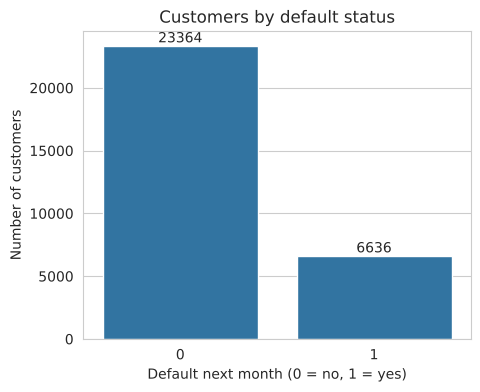

Default rate: 22.12 %
Ratio non-default : default = 3.52 : 1


In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="default", data=eda)
plt.title("Customers by default status")
plt.xlabel("Default next month (0 = no, 1 = yes)")
plt.ylabel("Number of customers")
for bar in ax.patches:
    ax.annotate(int(bar.get_height()), (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
plt.show()

print("Default rate:", round(eda["default"].mean() * 100, 2), "%")
print("Ratio non-default : default =", round((eda["default"] == 0).sum() / (eda["default"] == 1).sum(), 2), ": 1")

**Interpretation.** 6,636 of the 30,000 customers (22.12%) defaulted, a ratio of about 3.5 non-defaulters to every defaulter. The classes are moderately imbalanced. A model that simply predicted "no default" for everyone would be about 77.9% accurate while catching no defaulters at all, which is why accuracy alone is not used to judge models in this project.

### 4.2 Numerical feature distributions: defaulters vs non-defaulters
Each histogram is normalised (`stat="density"`, `common_norm=False`) so the two groups can be compared fairly even though non-defaulters are more numerous.

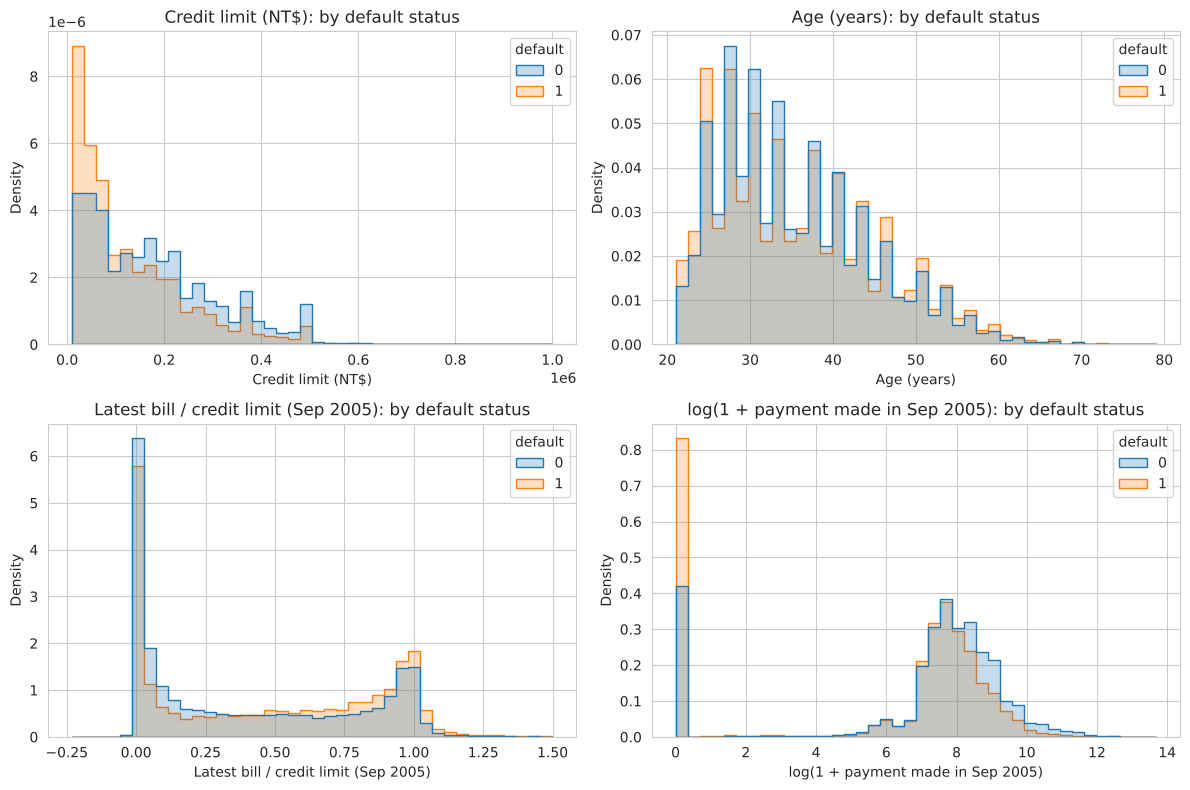

Median values by default status:


,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1,utilisation
default,,,,,
0,150000.0,34.0,23119.5,2459.5,0.267
1,90000.0,34.0,20185.0,1636.0,0.493


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_info = [("LIMIT_BAL", "Credit limit (NT$)"),
             ("AGE", "Age (years)"),
             ("utilisation", "Latest bill / credit limit (Sep 2005)"),
             ("log_PAY_AMT1", "log(1 + payment made in Sep 2005)")]

for ax, (col, label) in zip(axes.ravel(), plot_info):
    data_to_plot = eda[(eda[col] > -0.5) & (eda[col] < 1.5)] if col == "utilisation" else eda
    sns.histplot(data=data_to_plot, x=col, hue="default", bins=40, stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{label}: by default status")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

print("Median values by default status:")
display(eda.groupby("default")[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1", "utilisation"]].median().round(3))

**Interpretation.**
- **Credit limit:** defaulters are concentrated at lower limits (median NT$90,000 vs NT$150,000 for non-defaulters).
- **Age:** the two groups have the same median (34) and the distributions overlap heavily, so age looks like a weak signal on its own.
- **Utilisation:** the median latest bill is about 49% of the limit for defaulters vs 27% for non-defaulters.
- **Payments:** the median September payment is lower for defaulters (NT$1,636 vs NT$2,460), and the spike at "no payment" (log value 0) is clearly taller for defaulters.

These are associations between groups, not proof that any one variable *causes* default.

### 4.3 Credit limit and bill-statement (utilisation) patterns
I group customers into credit-limit quintiles and into bands of utilisation, then compute the default rate in each group.

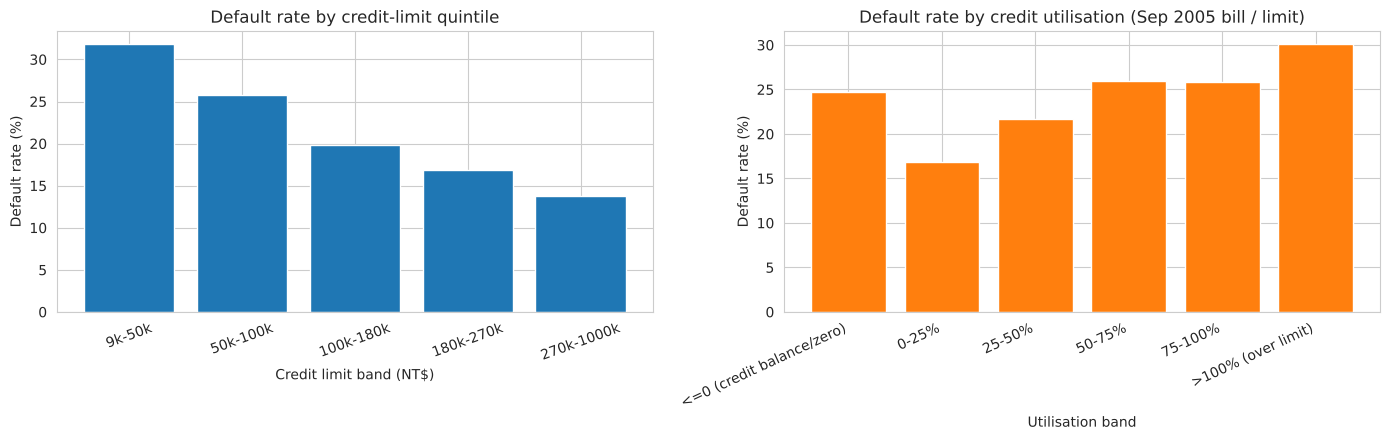

,mean,count
limit_band,,
"(9999.999, 50000.0]",0.3179,7676
"(50000.0, 100000.0]",0.2580,4822
"(100000.0, 180000.0]",0.1986,6123
"(180000.0, 270000.0]",0.1686,5421
"(270000.0, 1000000.0]",0.1380,5958


,mean,count
util_band,,
<=0 (credit balance/zero),0.2475,2598
0-25%,0.1681,11440
25-50%,0.2174,3588
50-75%,0.2596,3579
75-100%,0.2582,6680
>100% (over limit),0.3007,2115


In [12]:
eda["limit_band"] = pd.qcut(eda["LIMIT_BAL"], q=5, duplicates="drop")
eda["util_band"] = pd.cut(eda["utilisation"], bins=[-np.inf, 0, 0.25, 0.5, 0.75, 1.0, np.inf],
                          labels=["<=0 (credit balance/zero)", "0-25%", "25-50%", "50-75%", "75-100%", ">100% (over limit)"])

limit_rate = eda.groupby("limit_band", observed=True)["default"].agg(["mean", "count"])
util_rate = eda.groupby("util_band", observed=True)["default"].agg(["mean", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(range(len(limit_rate)), limit_rate["mean"] * 100)
axes[0].set_xticks(range(len(limit_rate)))
axes[0].set_xticklabels([f"{int(i.left/1000)}k-{int(i.right/1000)}k" for i in limit_rate.index], rotation=20)
axes[0].set_title("Default rate by credit-limit quintile")
axes[0].set_xlabel("Credit limit band (NT$)")
axes[0].set_ylabel("Default rate (%)")

axes[1].bar(range(len(util_rate)), util_rate["mean"] * 100, color="tab:orange")
axes[1].set_xticks(range(len(util_rate)))
axes[1].set_xticklabels(util_rate.index, rotation=25, ha="right")
axes[1].set_title("Default rate by credit utilisation (Sep 2005 bill / limit)")
axes[1].set_xlabel("Utilisation band")
axes[1].set_ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

display(limit_rate.round(4))
display(util_rate.round(4))

**Interpretation.** The default rate falls steadily as the credit limit rises: 31.8% in the lowest-limit quintile (up to NT$50,000) down to 13.8% in the highest. Utilisation shows a rise from 16.8% (0-25% of limit used) to 26.0% (50-75%) and 30.1% for customers whose bill is above their limit. The "zero or negative bill" group (24.8%) mixes customers with credit balances and inactive accounts, so it does not follow the pattern.

*Caution:* the bank itself set these limits, probably giving smaller limits to customers it already judged riskier. So the limit partly reflects the bank's earlier risk view; it is not necessarily a cause of default.

### 4.4 Repayment status and payment behaviour
`PAY_1` (September repayment status) is the most recent repayment signal. I also count in how many of the six months the customer was late.

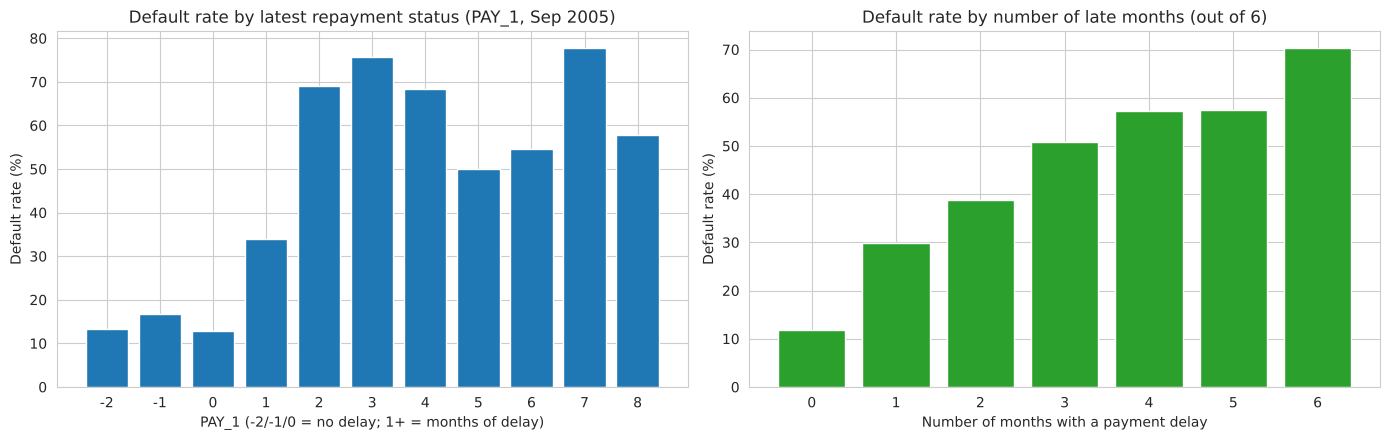

Default rate and customer count by PAY_1:


,mean,count
PAY_1,,
-2,0.1323,2759
-1,0.1678,5686
0,0.1281,14737
1,0.3395,3688
2,0.6914,2667
3,0.7578,322
4,0.6842,76
5,0.5000,26
6,0.5455,11


Default rate and customer count by number of late months:


,mean,count
months_late,,
0,0.1171,19931
1,0.2982,4426
2,0.3876,1899
3,0.5087,1154
4,0.5731,951
5,0.5738,298
6,0.7032,1341


In [13]:
pay1_rate = eda.groupby("PAY_1")["default"].agg(["mean", "count"])
late_rate = eda.groupby("months_late")["default"].agg(["mean", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(pay1_rate.index.astype(str), pay1_rate["mean"] * 100)
axes[0].set_title("Default rate by latest repayment status (PAY_1, Sep 2005)")
axes[0].set_xlabel("PAY_1 (-2/-1/0 = no delay; 1+ = months of delay)")
axes[0].set_ylabel("Default rate (%)")

axes[1].bar(late_rate.index.astype(str), late_rate["mean"] * 100, color="tab:green")
axes[1].set_title("Default rate by number of late months (out of 6)")
axes[1].set_xlabel("Number of months with a payment delay")
axes[1].set_ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

print("Default rate and customer count by PAY_1:")
display(pay1_rate.round(4))
print("Default rate and customer count by number of late months:")
display(late_rate.round(4))

**Interpretation.** Repayment status is the strongest pattern so far. Customers with status -2, -1 or 0 (no delay) default at 12.8%-16.8%. The rate jumps to 34.0% for a one-month delay and 69.1% for two months, and is about 76% for three months. Statuses of 4 or more have very few customers (76 or fewer each), so their rates are noisy. The number of late months tells the same story: from 11.7% with no late month to 70.3% when all six months were late.

One detail: status -1 ("paid duly", 16.8%) has a *higher* default rate than status 0 (12.8%). So the codes are not a perfectly smooth risk scale at the low end, which is one reason to test non-linear models and not rely only on a straight-line relationship.

### 4.5 Categorical features: education, marriage and sex
These are shown for **descriptive understanding only**. `SEX` and `MARRIAGE` are personal characteristics that regulators in many countries do not allow lenders to use when taking credit decisions, so they will be excluded from the predictive features (Section 5). Raw codes are used here, including the undocumented ones.

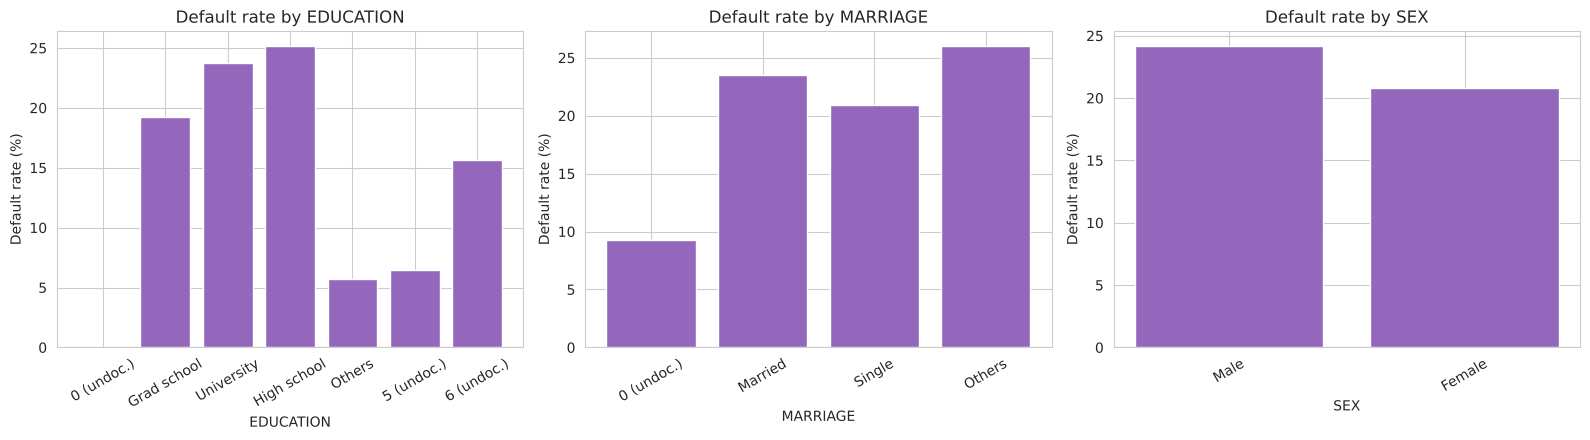


EDUCATION: default rate and count


,mean,count
EDUCATION,,
0,0.0000,14
1,0.1923,10585
2,0.2373,14030
3,0.2516,4917
4,0.0569,123
5,0.0643,280
6,0.1569,51



MARRIAGE: default rate and count


,mean,count
MARRIAGE,,
0,0.0926,54
1,0.2347,13659
2,0.2093,15964
3,0.2601,323



SEX: default rate and count


,mean,count
SEX,,
1,0.2417,11888
2,0.2078,18112


In [14]:
edu_labels = {0: "0 (undoc.)", 1: "Grad school", 2: "University", 3: "High school", 4: "Others", 5: "5 (undoc.)", 6: "6 (undoc.)"}
mar_labels = {0: "0 (undoc.)", 1: "Married", 2: "Single", 3: "Others"}
sex_labels = {1: "Male", 2: "Female"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, labels in zip(axes, ["EDUCATION", "MARRIAGE", "SEX"], [edu_labels, mar_labels, sex_labels]):
    rate = eda.groupby(col)["default"].mean() * 100
    ax.bar([labels[i] for i in rate.index], rate.values, color="tab:purple")
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Default rate (%)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

for col in ["EDUCATION", "MARRIAGE", "SEX"]:
    print(f"\n{col}: default rate and count")
    display(eda.groupby(col)["default"].agg(["mean", "count"]).round(4))

**Interpretation.** Among the documented education groups the default rate is 19.2% (graduate school), 23.7% (university) and 25.2% (high school). The undocumented codes (0, 5, 6) and the "others" code (4) have very few customers (14 to 280) and low default rates, so those percentages are unreliable. By marital status: married 23.5%, single 20.9%, others 26.0% (323 customers). By sex: male 24.2%, female 20.8%. These differences are modest, are not controlled for other factors, and say nothing about cause. `SEX` and `MARRIAGE` are not used in the models (Section 5.7).

### 4.6 Correlation analysis

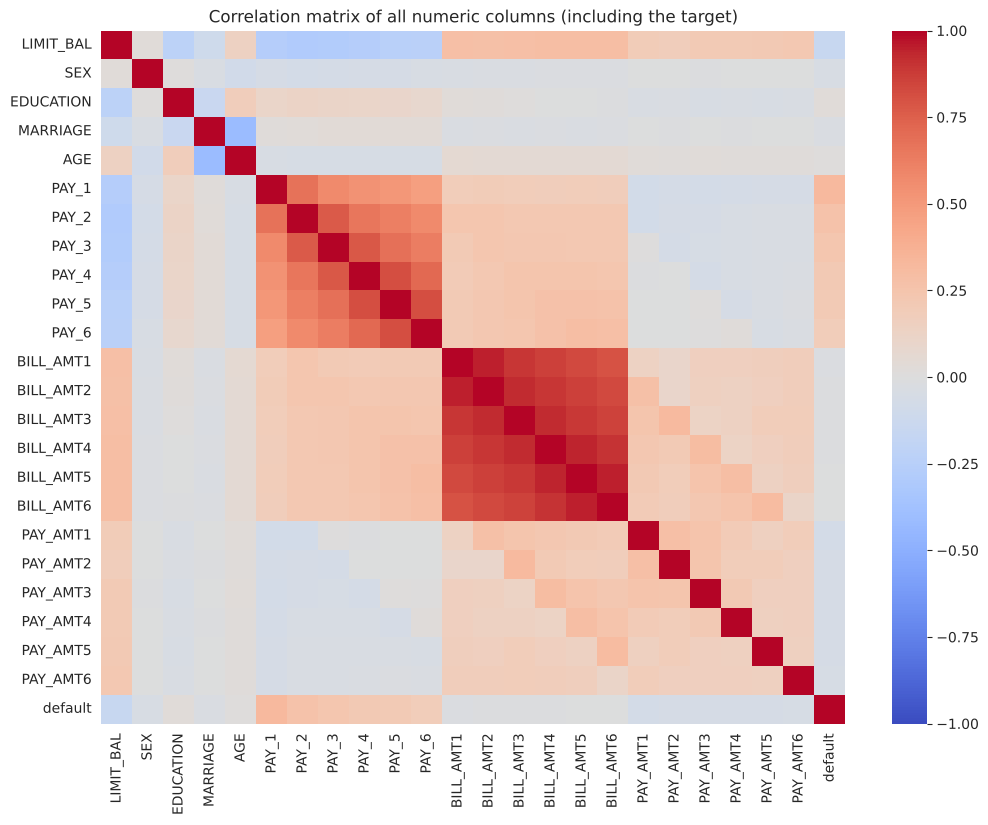

Correlation of each feature with default (sorted by absolute value):


,corr with default
PAY_1,0.325
PAY_2,0.264
PAY_3,0.235
PAY_4,0.217
PAY_5,0.204
PAY_6,0.187
LIMIT_BAL,-0.154
PAY_AMT1,-0.073
PAY_AMT2,-0.059
PAY_AMT4,-0.057


Average correlation among the six BILL_AMT columns: 0.886
Average correlation among the six PAY_ columns:     0.656


In [15]:
corr = df.drop(columns="ID").corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix of all numeric columns (including the target)")
plt.show()

print("Correlation of each feature with default (sorted by absolute value):")
target_corr = corr["default"].drop("default")
display(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3).to_frame("corr with default"))

print("Average correlation among the six BILL_AMT columns:",
      round(df[bill_cols].corr().values[np.triu_indices(6, k=1)].mean(), 3))
print("Average correlation among the six PAY_ columns:    ",
      round(df[pay_cols].corr().values[np.triu_indices(6, k=1)].mean(), 3))

**Interpretation.** The repayment-status variables have the highest correlation with default: `PAY_1` at 0.325 and `PAY_2` to `PAY_6` between 0.19 and 0.26. `LIMIT_BAL` is negative (-0.154) and the payment amounts are weakly negative (about -0.05 to -0.07). The bill amounts and age are close to zero, so there is almost no straight-line relationship between them and default.

The six bill columns are very strongly correlated with each other (average correlation 0.886), and the `PAY_` columns are also related (0.656). This **multicollinearity** means that similar information is repeated, which makes coefficient-based interpretation unreliable and splits importance among related variables later.

Correlation measures straight-line association only. It does not show causation, and a low correlation does not rule out a useful non-linear relationship.

---
## Section 5: Data Cleaning and Feature Preparation

I inspect each potential problem and decide *with a reason*, rather than dropping unusual values automatically.

### 5.1 Missing values and data types

In [16]:
print("Missing values per column (all zero means none):", df.isnull().sum().sum())
print("Data types:", df.dtypes.unique())

Missing values per column (all zero means none): 0
Data types: [dtype('int64')]


No missing values and every column is numeric, so **no imputation is needed**. (If imputation had been needed it would be placed inside the Pipeline so that it is learned from training data only.)

### 5.2 Duplicate observations
There are no exact duplicate rows, but some rows are identical in all 23 predictors and the target when ID is ignored. I look at them before deciding.

In [17]:
dup_mask = df.drop(columns="ID").duplicated(keep=False)
dups = df[dup_mask]
print("Rows involved in a duplicate group (ID ignored):", len(dups))

all_zero_activity = (dups[bill_cols + pay_amt_cols] == 0).all(axis=1).sum()
print("Of these, rows with every bill and every payment equal to zero:", all_zero_activity)
display(dups.sort_values(["LIMIT_BAL", "AGE", "ID"]).head(8))

Rows involved in a duplicate group (ID ignored): 70
Of these, rows with every bill and every payment equal to zero: 60


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
12430,12431,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
14294,14295,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
7170,7171,50000,2,1,2,23,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
17032,17033,50000,2,1,2,23,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
1759,1760,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
10250,10251,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
21768,21769,80000,2,2,2,25,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
27765,27766,80000,2,2,2,25,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0


**Decision: keep them.** 70 rows form 35 pairs that are identical in all predictors and the target but have different IDs. 60 of these 70 rows have **zero bills and zero payments in all six months**, i.e. inactive accounts with the same limit, age and profile. Such rows naturally look identical, so they are most likely genuinely different customers and not data-entry errors. I cannot prove they are errors, and removing 35 rows out of 30,000 (0.12%) would not change the conclusions. If a pair were split between the training and test sets it would slightly flatter the test score, but the effect is negligible at this size.

### 5.3 The `ID` column
`ID` is a row identifier. It has no business meaning, and if rows were ordered in some hidden way it could leak information. It is **excluded from the features** in Section 6.

### 5.4 Unexpected category codes
`EDUCATION` and `MARRIAGE` contain codes that are not in the official description.

In [18]:
print("EDUCATION counts (documented codes are 1-4):")
print(df["EDUCATION"].value_counts().sort_index().to_string())
print("\nMARRIAGE counts (documented codes are 1-3):")
print(df["MARRIAGE"].value_counts().sort_index().to_string())

print("\nDefault rate of the undocumented groups:")
print("EDUCATION in (0, 5, 6):", round(df.loc[df["EDUCATION"].isin([0, 5, 6]), "default"].mean(), 4),
      "| EDUCATION = 4 (others):", round(df.loc[df["EDUCATION"] == 4, "default"].mean(), 4))
print("MARRIAGE = 0:", round(df.loc[df["MARRIAGE"] == 0, "default"].mean(), 4),
      "| MARRIAGE = 3 (others):", round(df.loc[df["MARRIAGE"] == 3, "default"].mean(), 4))

EDUCATION counts (documented codes are 1-4):
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

MARRIAGE counts (documented codes are 1-3):
MARRIAGE
0       54
1    13659
2    15964
3      323

Default rate of the undocumented groups:
EDUCATION in (0, 5, 6): 0.0754 | EDUCATION = 4 (others): 0.0569
MARRIAGE = 0: 0.0926 | MARRIAGE = 3 (others): 0.2601


**Decision.** `EDUCATION` codes 0, 5 and 6 (345 customers together) have a default rate of 7.5%, close to the documented "others" group (code 4: 123 customers, 5.7%), so I merge all of them into "others" (code 4), giving 468 customers. `MARRIAGE` code 0 (54 customers) is merged into "others" (code 3) only for tidiness. Its default rate (9.3%) is actually different from group 3 (26.0%), but it is a tiny group and `MARRIAGE` is not used as a feature anyway. I do not drop these customers, because dropping them would lose data without a clear reason.

In [19]:
# Rule-based recoding (a fixed rule that does not learn anything from the data, so it is safe before splitting)
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("EDUCATION after recoding:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE after recoding: ", sorted(df["MARRIAGE"].unique()))

EDUCATION after recoding: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE after recoding:  [np.int64(1), np.int64(2), np.int64(3)]


### 5.5 Repayment status codes (`PAY_1` ... `PAY_6`)
The values -2 and 0 are not in the documentation. A common interpretation is: -2 = no consumption, -1 = paid in full, 0 = used revolving credit (paid at least the minimum). That interpretation is **not confirmed by the file**, so I do not recode anything. I keep the values as **ordered numbers**: larger values mean more months of delay, which is the relationship the EDA showed. I also do not remove rows with these values because they are a large share of the customers.

### 5.6 Potentially problematic numeric values

In [20]:
print("Rows with a negative bill (credit balance) in any month:", (df[bill_cols] < 0).any(axis=1).sum())
print("Rows where the Sep bill is above the credit limit:      ", (df["BILL_AMT1"] > df["LIMIT_BAL"]).sum())
print("Rows with zero payment in Sep (PAY_AMT1 = 0):           ", (df["PAY_AMT1"] == 0).sum())
print("Age range:", df["AGE"].min(), "to", df["AGE"].max())
print("\nSkewness of money columns (large positive = long right tail):")
print(df[["LIMIT_BAL"] + bill_cols + pay_amt_cols].skew().round(2).to_string())

Rows with a negative bill (credit balance) in any month: 1930
Rows where the Sep bill is above the credit limit:       2115
Rows with zero payment in Sep (PAY_AMT1 = 0):            5249
Age range: 21 to 79

Skewness of money columns (large positive = long right tail):
LIMIT_BAL     0.99
BILL_AMT1     2.66
BILL_AMT2     2.71
BILL_AMT3     3.09
BILL_AMT4     2.82
BILL_AMT5     2.88
BILL_AMT6     2.85
PAY_AMT1     14.67
PAY_AMT2     30.45
PAY_AMT3     17.22
PAY_AMT4     12.90
PAY_AMT5     11.13
PAY_AMT6     10.64


**Decision: keep all of them.**
- 1,930 customers have a negative bill in at least one month (a credit balance, for example after an overpayment or refund) and 2,115 have a September bill above their limit. Both are plausible real situations.
- 5,249 customers (17.5%) paid nothing in September, which is meaningful behaviour.
- Ages run from 21 to 79 with no impossible values.
- The money columns are strongly right-skewed (skewness up to 30 for `PAY_AMT2`). The large amounts are real, so I do not remove them. Tree models are not affected by skew. For Logistic Regression and the Neural Network I only standardise the values; a log transform could be a future improvement but I kept the pipeline simple.

### 5.7 Sensitive attributes
I **exclude `SEX` and `MARRIAGE`** from the predictive features. They are personal characteristics and using them for a real credit decision would be inappropriate or unlawful in many jurisdictions. Excluding them does not remove all bias risk (other variables can act as proxies), so fairness testing would still be required before any real use (Section 14). `AGE` and `EDUCATION` are kept as general profile variables, but they also need fairness review in real use.

### 5.8 Summary of cleaning decisions
| Issue | Decision | Reason |
|---|---|---|
| Missing values | None, nothing to impute | Verified |
| Exact duplicates | None | Verified |
| Rows identical when ID ignored | Kept | Different IDs and not confirmable as errors; see 5.2 |
| `ID` | Not used as a feature | Identifier only |
| `EDUCATION` 0, 5, 6 | Merged into 4 ("others") | Undocumented codes with small counts |
| `MARRIAGE` 0 | Merged into 3 ("others") | Undocumented code with small count (not used as a feature anyway) |
| `PAY_` codes -2 and 0 | Kept as ordered numbers | Meaning unconfirmed; not removing real information |
| Negative bills / over-limit bills | Kept | Plausible real situations (credit balance, over-limit) |
| `SEX`, `MARRIAGE` | Excluded from features | Sensitive attributes |

---
## Section 6: Define Features and Target

In [21]:
sensitive_columns = ["SEX", "MARRIAGE"]

X = df.drop(columns=["ID", "default"] + sensitive_columns)   # no ID, no target, no sensitive columns
y = df["default"]

print("X shape:", X.shape)
print("Features used:", X.columns.tolist())
print("\nTarget meaning: 0 = did not default next month, 1 = defaulted next month (positive class)")
print(y.value_counts().sort_index().to_string())

X shape: (30000, 21)
Features used: ['LIMIT_BAL', 'EDUCATION', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Target meaning: 0 = did not default next month, 1 = defaulted next month (positive class)
default
0    23364
1     6636


### Stratified train-test split
I use an 80/20 split with `stratify=y` so both parts keep the same default rate, and a fixed `random_state` for reproducibility. **The test set is used only once, for final evaluation.** All model comparison, tuning and threshold selection use the training set only.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Default rate in train:", round(y_train.mean(), 4), "| in test:", round(y_test.mean(), 4))

Train: (24000, 21) | Test: (6000, 21)
Default rate in train: 0.2212 | in test: 0.2212


---
## Section 7: Preprocessing

### Why preprocessing must be fitted on training data only
Scaling uses the mean and standard deviation of a column. If those were computed on the full dataset, information from the test customers would influence how training data is prepared. That is **data leakage**: the test score would look slightly better than it should. The same applies inside cross-validation, where the validation fold must be treated like unseen data.

The solution is a scikit-learn **`Pipeline`**: preprocessing and model are bundled together, and when `.fit()` is called only the training data is used to learn the scaling values. When `.predict()` is called, the same already-learned values are applied to new data.

### What the preprocessor does
- **`StandardScaler`** on the numeric columns (credit limit, age, repayment status, bills, payments). This is required by Logistic Regression and the Neural Network, and harmless for tree models. I apply the same preprocessing to all models so the comparison is fair.
- **`OneHotEncoder`** on `EDUCATION`. Education is a *category* (no sensible numeric order between "high school" and "others"), so it is converted into 0/1 indicator columns.
- The `PAY_` columns stay numeric because they are naturally ordered (more months of delay = larger number).
- No imputation is needed (no missing values) and **no resampling (SMOTE) is used**.

In [23]:
categorical_features = ["EDUCATION"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

# Demonstration: fit on TRAIN only and check that the learned mean differs slightly from the full-data mean
demo = clone(preprocessor).fit(X_train)
print("Processed training matrix shape:", demo.transform(X_train).shape)
print("LIMIT_BAL mean learned from train only:", round(demo.named_transformers_["num"].mean_[numeric_features.index("LIMIT_BAL")], 1))
print("LIMIT_BAL mean of the full dataset    :", round(X["LIMIT_BAL"].mean(), 1))
print("Test rows are transformed with the TRAIN mean and standard deviation, never their own.")

Processed training matrix shape: (24000, 24)
LIMIT_BAL mean learned from train only: 167364.7
LIMIT_BAL mean of the full dataset    : 167484.3
Test rows are transformed with the TRAIN mean and standard deviation, never their own.


**Note on `clone()`:** a `Pipeline` fits its steps *in place*. If several pipelines shared the same `preprocessor` object, fitting one would overwrite another. I therefore give each pipeline its own copy using `clone(preprocessor)`.

---
## Section 8: Baseline Machine Learning Models

All models use **the same train/test split, the same preprocessing and the same target**, so the comparison is fair.

### Intuition behind each model
- **Logistic Regression:** computes a weighted sum of the features and converts it into a probability between 0 and 1 with the sigmoid function. Each weight shows the direction of association of a feature. It is simple, fast and easy to explain, but can only draw a straight-line (linear) boundary.
- **Decision Tree:** asks a sequence of yes/no questions ("is PAY_1 greater than 1?") and ends in a leaf with a default probability. Easy to read, but a deep tree memorises the training data (overfitting). I limit the depth and the minimum leaf size to control this.
- **Random Forest:** builds many trees, each on a random sample of rows and features, and averages them. Averaging reduces the overfitting of any single tree.
- **Gradient Boosting:** builds small trees one after another, where each new tree tries to correct the mistakes of the previous ones. It often performs very well on tabular data but needs careful settings.

### How imbalance is handled
About 22% of customers default. I **do not reweight or resample the classes**, so the predicted probabilities stay honest (and can be judged with the Brier score). Instead, models are compared with imbalance-aware metrics and the decision threshold is chosen from training data in Section 9.

### Out-of-fold predictions (new technique)
`cross_val_predict` with 5-fold `StratifiedKFold` gives each *training* customer a probability predicted by a model that **did not see that customer**. This is a fair, test-free estimate of performance on the training data. I use it for model ranking and for choosing the decision threshold. The preprocessing happens inside each fold because it is part of the Pipeline.

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

pipelines  = {}   # fitted pipelines (preprocessing + model)
oof_probs  = {}   # out-of-fold probabilities on the training set
test_probs = {}   # probabilities on the test set (used for final evaluation only)
train_auc  = {}

for name, model in baseline_models.items():
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)                                    # fit on training data only
    pipelines[name]  = pipe
    train_auc[name]  = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_probs[name] = pipe.predict_proba(X_test)[:, 1]
    oof_probs[name]  = cross_val_predict(pipe, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
    print("finished:", name)

finished: Logistic Regression


finished: Decision Tree


finished: Random Forest


finished: Gradient Boosting


### Evaluation helper
To avoid repeating the same ten lines for every model, I use one small function that turns probabilities and a threshold into the metrics defined in Section 9. It contains nothing new: it just calls the metric functions I already know.

In [25]:
def evaluate_model(name, y_true, prob, threshold=0.5):
    """Return a dictionary of metrics for one model at one decision threshold."""
    pred = (prob >= threshold).astype(int)
    return {
        "Model": name,
        "Threshold": round(float(threshold), 3),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "Avg Precision": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob),
    }

# Baseline results on the held-out test set at the standard 0.5 threshold
results_default = [evaluate_model(n, y_test, test_probs[n], 0.5) for n in baseline_models]
display(pd.DataFrame(results_default).set_index("Model").round(4))

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Model,,,,,,,,
Logistic Regression,0.5,0.8090,0.6946,0.2434,0.3605,0.7066,0.4911,0.1469
Decision Tree,0.5,0.8172,0.6624,0.3534,0.4609,0.7417,0.4970,0.1396
Random Forest,0.5,0.8168,0.6583,0.3572,0.4631,0.7716,0.5526,0.1358
Gradient Boosting,0.5,0.8175,0.6611,0.3587,0.4651,0.7782,0.5554,0.1354


### Overfitting check and training-side ranking
Comparing the AUC on the data the model was trained on, on out-of-fold training data, and on the test set shows how much each model overfits.

In [26]:
fit_check = pd.DataFrame({
    "Train AUC (in-sample)": pd.Series(train_auc),
    "CV AUC (out-of-fold)": pd.Series({n: roc_auc_score(y_train, oof_probs[n]) for n in baseline_models}),
    "CV Avg Precision (out-of-fold)": pd.Series({n: average_precision_score(y_train, oof_probs[n]) for n in baseline_models}),
    "Test AUC": pd.Series({n: roc_auc_score(y_test, test_probs[n]) for n in baseline_models}),
})
fit_check["Train - CV AUC gap"] = fit_check["Train AUC (in-sample)"] - fit_check["CV AUC (out-of-fold)"]
display(fit_check.round(4))

,Train AUC (in-sample),CV AUC (out-of-fold),CV Avg Precision (out-of-fold),Test AUC,Train - CV AUC gap
Logistic Regression,0.7284,0.7263,0.5053,0.7066,0.0022
Decision Tree,0.7657,0.7593,0.5341,0.7417,0.0064
Random Forest,0.9293,0.7821,0.5569,0.7716,0.1472
Gradient Boosting,0.8058,0.7807,0.5525,0.7782,0.0251


**Interpretation.**
- At the standard 0.5 threshold all four models look similar on **accuracy** (80.9% to 81.8%), which hides real differences. **Recall** at 0.5 is low: 24.3% for Logistic Regression and only about 35-36% for the tree-based models, i.e. at 0.5 most defaulters are missed.
- Ranking by **ROC-AUC**, **average precision** and **Brier score** gives a consistent order: Gradient Boosting (AUC 0.778, AP 0.555, Brier 0.1354) and Random Forest (0.772, 0.553, 0.1358) are best, then the Decision Tree (0.742, 0.497), then Logistic Regression (0.707, 0.491). For reference, a model that always predicted the overall default rate would have a Brier score of about 0.172, so all models are better than that.
- **Overfitting check:** the Random Forest scores 0.929 AUC on its own training data but 0.782 out-of-fold, a large gap of 0.147, so it memorises the training data. Even so, its out-of-fold performance is the best of the four, so the gap alone is not a reason to reject it. Gradient Boosting has a gap of 0.025, while Logistic Regression (0.002) and the shallow tree (0.006) barely overfit but also score lower. Their lower scores suggest they are limited by their form (a straight line, or a very shallow tree) and not by overfitting.
- Test AUCs are close to, but somewhat below, the out-of-fold AUCs (for example Logistic Regression 0.707 vs 0.726). Differences of this size are normal sampling variation and are a reminder that single-split numbers are noisy.

---
## Section 9: Model Evaluation

### Metrics used
With 22% defaulters, a model that predicts "no default" for everyone would be about 78% accurate yet useless. So several metrics are used:

| Metric | What it tells us |
|---|---|
| **Accuracy** | Share of all customers classified correctly. Misleading with imbalance. |
| **Precision** | Of customers flagged as defaulters, how many truly defaulted. Low precision means many good customers are wrongly flagged. |
| **Recall** | Of all true defaulters, how many were caught. Low recall means many defaulters are missed. |
| **F1-score** | Harmonic mean of precision and recall; a single balance of the two. |
| **ROC-AUC** | Probability that a random defaulter gets a higher score than a random non-defaulter. Does not depend on the threshold. |
| **Average Precision (PR-AUC)** | Area under the precision-recall curve. Focuses on the positive (default) class, so it is more informative than ROC-AUC when positives are rare. |
| **Brier score** | Mean squared error of the predicted probabilities (lower is better). Measures whether the probabilities themselves are reliable. |

### False positives and false negatives in credit risk
- **False negative (FN):** a customer who defaults but the model said "safe". The bank misses a warning and may lose the outstanding balance. This is usually the more expensive error.
- **False positive (FP):** a customer who would have repaid but is flagged as risky. The bank may reduce a limit or spend collection effort unnecessarily and may damage the customer relationship.

Which error matters more depends on the bank's actual costs, which are not in this dataset, so I do not invent them.

### Choosing the decision threshold without touching the test set
By default a probability of 0.5 or above is called "default". With imbalanced data 0.5 is usually too high, so recall is low. I choose, for each model, the threshold that **maximises F1 on the out-of-fold training predictions**. The test set plays no part in this choice, and the threshold is then applied unchanged to the test set.

In [27]:
def choose_threshold(y_true, prob):
    """Threshold that gives the highest F1 on the given (training-side) probabilities."""
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return thresholds[np.argmax(f1_values)]

best_threshold = {n: choose_threshold(y_train, oof_probs[n]) for n in baseline_models}
print("F1-optimal thresholds chosen on out-of-fold training predictions:")
print({n: round(float(t), 3) for n, t in best_threshold.items()})

results_tuned_thr = [evaluate_model(n, y_test, test_probs[n], best_threshold[n]) for n in baseline_models]
print("\nTest-set results at the training-chosen threshold:")
display(pd.DataFrame(results_tuned_thr).set_index("Model").round(4))

F1-optimal thresholds chosen on out-of-fold training predictions:
{'Logistic Regression': 0.277, 'Decision Tree': 0.298, 'Random Forest': 0.293, 'Gradient Boosting': 0.255}

Test-set results at the training-chosen threshold:


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Model,,,,,,,,
Logistic Regression,0.277,0.7863,0.5183,0.4808,0.4988,0.7066,0.4911,0.1469
Decision Tree,0.298,0.8003,0.5566,0.4778,0.5142,0.7417,0.4970,0.1396
Random Forest,0.293,0.7893,0.5223,0.5569,0.5390,0.7716,0.5526,0.1358
Gradient Boosting,0.255,0.7820,0.5064,0.5682,0.5355,0.7782,0.5554,0.1354


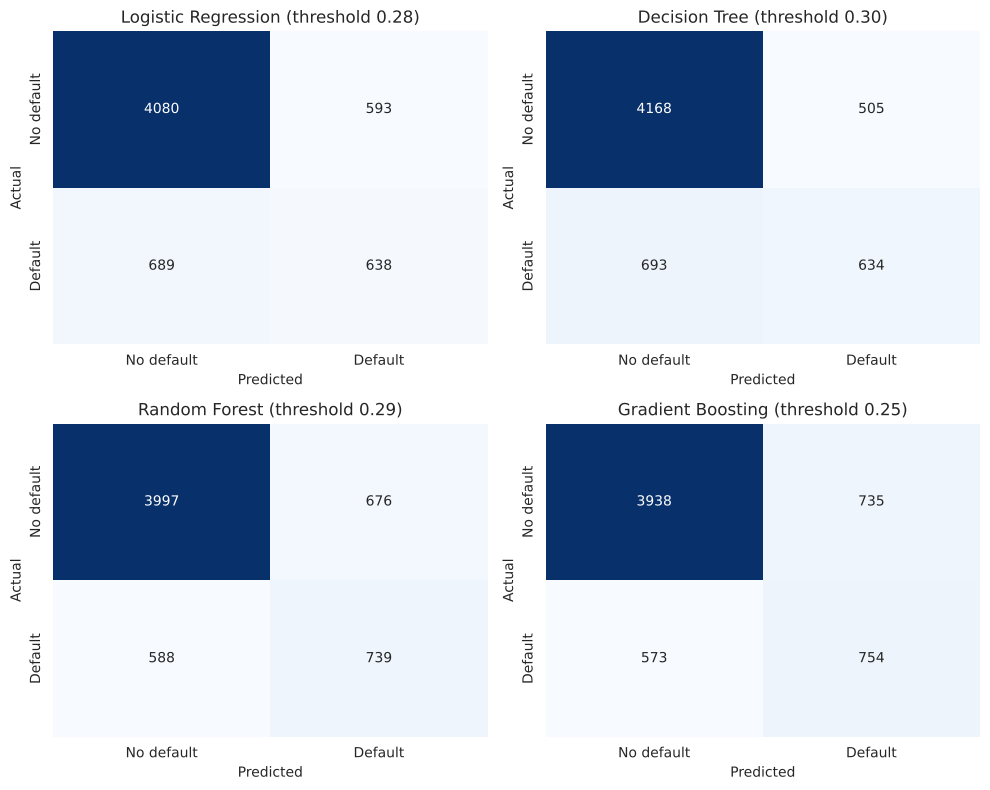

In [28]:
# Confusion matrices on the test set at the training-chosen thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name in zip(axes.ravel(), baseline_models):
    pred = (test_probs[name] >= best_threshold[name]).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No default", "Default"], yticklabels=["No default", "Default"])
    ax.set_title(f"{name} (threshold {best_threshold[name]:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

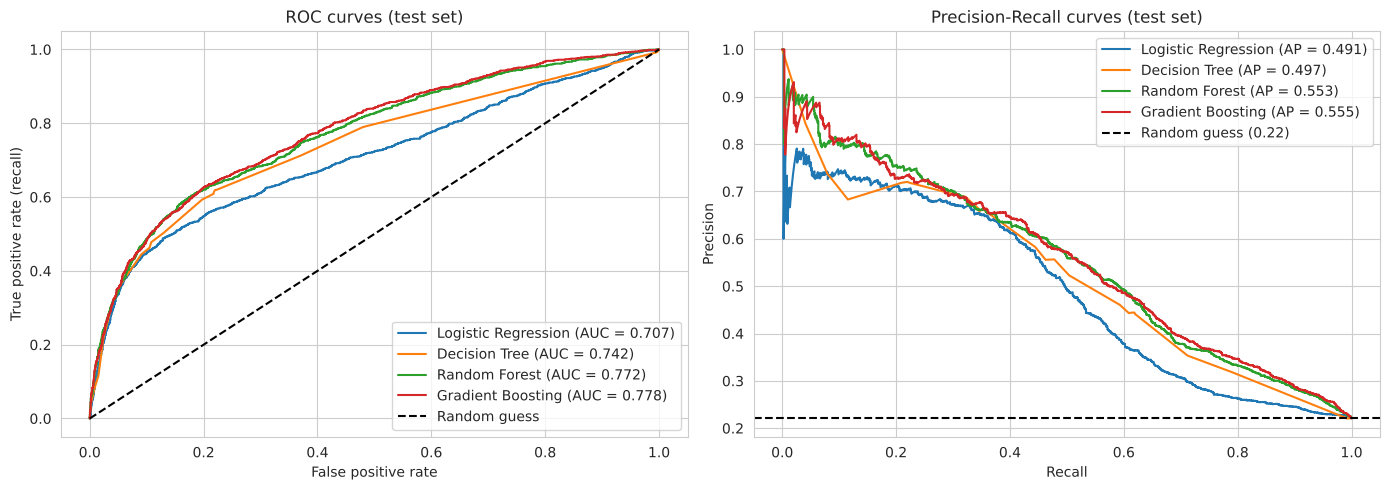

In [29]:
# ROC and Precision-Recall curves on the test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in baseline_models:
    fpr, tpr, _ = roc_curve(y_test, test_probs[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, test_probs[name]):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, test_probs[name])
    axes[1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, test_probs[name]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[0].set_title("ROC curves (test set)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate (recall)")
axes[0].legend()
axes[1].axhline(y_test.mean(), color="k", linestyle="--", label=f"Random guess ({y_test.mean():.2f})")
axes[1].set_title("Precision-Recall curves (test set)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretation.**
- **Effect of the threshold:** the F1-optimal thresholds chosen on the training data (0.255 to 0.298) are well below 0.5. Moving to them raises recall from 24-36% to 48-57% and lowers precision from 66-69% to 51-56%. F1 rises for every model (Logistic Regression 0.361 to 0.499, Random Forest 0.463 to 0.539, Gradient Boosting 0.465 to 0.536) while accuracy falls by about 2-3.5 points (Gradient Boosting 81.8% to 78.2%). This is the precision-recall trade-off: the lower threshold catches more defaulters but also flags more good customers. For Gradient Boosting, for example, recall is 56.8% but about 49% of flagged customers are false alarms (1 - precision of 0.506).
- **Model comparison:** the threshold-free metrics (ROC-AUC, average precision, Brier) are unaffected by the threshold and give the same order as before: Gradient Boosting and Random Forest first, then the Decision Tree, then Logistic Regression. The ROC and precision-recall curves show the same picture: the Gradient Boosting and Random Forest curves almost overlap, and both lie above the Decision Tree and Logistic Regression curves over most of the range. On F1 at the chosen threshold, Random Forest (0.539) and Gradient Boosting (0.536) differ by too little to call one better.
- **Business reading:** false negatives (missed defaulters) are usually the costlier error for a lender, so a recall-oriented threshold can be justified, but the true costs are not in this dataset. The F1 criterion treats both errors as equally costly, which is only a neutral starting point.

---
## Section 10: Hyperparameter Tuning

### Which models to tune
I tune **two** models, chosen using the *training-side* evidence from Section 8 (out-of-fold average precision), not the test set. I do not tune the Decision Tree (a single tree is a weaker learner and is already depth-limited) or Logistic Regression (it has almost nothing worth tuning; its main limit is that it is linear).

In Section 8 the out-of-fold average precision on the training set was 0.557 for Random Forest and 0.553 for Gradient Boosting, ahead of the Decision Tree (0.534) and Logistic Regression (0.505). **Random Forest and Gradient Boosting** are therefore the two promising models. Both also have settings that control how complex the trees become, and the untuned Random Forest showed a large gap between in-sample and out-of-fold AUC (Section 8), so regularising it is worthwhile.

### Search design
- **Search method:** `GridSearchCV` for Gradient Boosting (small grid, so every combination can be tried) and `RandomizedSearchCV` for Random Forest (larger space, so 10 random combinations are sampled). Both were used in my coursework.
- **Cross-validation:** 5-fold **stratified** cross-validation on the training set only.
- **Preprocessing inside the search:** each search receives the whole `Pipeline`, so scaling is re-learned inside every training fold and validation folds stay unseen.
- **Scoring metric:** `average_precision`. The goal of a risk team is to rank customers so that defaulters appear near the top. Average precision measures exactly this for the rare positive class and does not depend on a threshold (the threshold is chosen afterwards). F1 would force the search to commit to one threshold too early.
- The parameter names start with `model__` because the model is the step called `model` inside the pipeline.
- Settings are kept small so the notebook runs in a reasonable time on a standard laptop.

In [30]:
# ---- Gradient Boosting: GridSearchCV ----
gb_pipe = Pipeline([("prep", clone(preprocessor)),
                    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])

gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [20],
}

gb_search = GridSearchCV(gb_pipe, gb_grid, cv=skf, scoring="average_precision", n_jobs=-1)
gb_search.fit(X_train, y_train)

print("Gradient Boosting - best parameters:", gb_search.best_params_)
print("Gradient Boosting - best CV average precision:", round(gb_search.best_score_, 4))

Gradient Boosting - best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 20, 'model__n_estimators': 100}
Gradient Boosting - best CV average precision: 0.5591


In [31]:
# ---- Random Forest: RandomizedSearchCV ----
rf_pipe = Pipeline([("prep", clone(preprocessor)),
                    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))])

rf_space = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [6, 8, 10, 12],
    "model__min_samples_leaf": [5, 10, 20, 40],
    "model__max_features": ["sqrt", 0.3],
}

rf_search = RandomizedSearchCV(rf_pipe, rf_space, n_iter=10, cv=skf, scoring="average_precision",
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Random Forest - best parameters:", rf_search.best_params_)
print("Random Forest - best CV average precision:", round(rf_search.best_score_, 4))

Random Forest - best parameters: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 0.3, 'model__max_depth': 8}
Random Forest - best CV average precision: 0.5622


In [32]:
# Add the tuned models to the same bookkeeping used for the baseline models
tuned_models = {"Gradient Boosting (tuned)": gb_search.best_estimator_,
                "Random Forest (tuned)": rf_search.best_estimator_}

for name, pipe in tuned_models.items():
    pipelines[name]  = pipe                                     # already refitted on the full training set
    train_auc[name]  = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_probs[name] = pipe.predict_proba(X_test)[:, 1]
    oof_probs[name]  = cross_val_predict(pipe, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
    best_threshold[name] = choose_threshold(y_train, oof_probs[name])
    results_default.append(evaluate_model(name, y_test, test_probs[name], 0.5))
    results_tuned_thr.append(evaluate_model(name, y_test, test_probs[name], best_threshold[name]))

compare = pd.DataFrame(results_tuned_thr).set_index("Model")
compare = compare.loc[["Random Forest", "Random Forest (tuned)", "Gradient Boosting", "Gradient Boosting (tuned)"]]
print("Untuned vs tuned on the untouched test set (training-chosen thresholds):")
display(compare.round(4))

print("Out-of-fold average precision on the training set (untuned vs tuned):")
display(pd.Series({n: average_precision_score(y_train, oof_probs[n]) for n in compare.index}).round(4).to_frame("CV Avg Precision"))

Untuned vs tuned on the untouched test set (training-chosen thresholds):


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Model,,,,,,,,
Random Forest,0.293,0.7893,0.5223,0.5569,0.5390,0.7716,0.5526,0.1358
Random Forest (tuned),0.245,0.7845,0.5112,0.5825,0.5446,0.7742,0.5540,0.1355
Gradient Boosting,0.255,0.7820,0.5064,0.5682,0.5355,0.7782,0.5554,0.1354
Gradient Boosting (tuned),0.240,0.7770,0.4965,0.5855,0.5373,0.7777,0.5549,0.1355


Out-of-fold average precision on the training set (untuned vs tuned):


,CV Avg Precision
Random Forest,0.5569
Random Forest (tuned),0.5598
Gradient Boosting,0.5525
Gradient Boosting (tuned),0.5574


**Interpretation.**
- **Best settings found.** Gradient Boosting: 100 trees, learning rate 0.05, depth 4, minimum leaf size 20 (cross-validated average precision 0.5591). Random Forest: 300 trees, depth 8, minimum leaf size 5, `max_features` = 0.3 (0.5622). These search scores are averages of the five fold scores, so they differ slightly from the pooled out-of-fold scores in the second table (RF 0.5569 to 0.5598, GB 0.5525 to 0.5574).
- **Gain is small.** Tuning improved cross-validated average precision by only about 0.003-0.005. On the untouched test set the changes are mixed and tiny: Random Forest average precision 0.5526 to 0.5540 and AUC 0.7716 to 0.7742; Gradient Boosting average precision 0.5554 to 0.5549 and AUC 0.7782 to 0.7777. All of these are far smaller than the sampling uncertainty shown in Section 12. The defaults were already close to the best that these models can do with these 21 features, which suggests the limit is set by the information in the data and not by the settings.
- The regularised Random Forest also became less overfitted by construction (depth capped at 8 instead of growing freely with small leaves), but I do not claim a measured improvement for that.
- The thresholds for the tuned models were chosen from out-of-fold predictions made with settings that were themselves picked on the same folds, so they may be very slightly optimistic. The test set was not involved.

---
## Section 11: Deep Learning: Artificial Neural Network

A **feed-forward neural network** is added as a *challenger* to the classical models. It is not assumed to be better; tree-based models are often very strong on tabular data like this.

### Key ideas in plain language
- **Neurons and hidden layers:** a neuron takes numbers in, combines them and passes a result on. Neurons are arranged in layers. *Hidden* layers sit between the input (our features) and the output (the default probability). Stacking layers lets the network learn combinations of features.
- **Weights and biases:** each connection has a *weight* (how strongly an input counts) and each neuron has a *bias* (a shift). Training means finding good values for all of them. Logistic Regression is the same idea with a single neuron.
- **Forward propagation:** data flows from the input layer through the hidden layers to the output, with each neuron computing *weighted sum + bias*, then applying an activation function.
- **ReLU activation** (hidden layers): `max(0, x)`. It outputs zero for negative values and passes positive values through. It lets the network model non-linear patterns and trains efficiently.
- **Sigmoid activation** (output layer): squashes any number into the range 0 to 1, so the single output can be read as the probability of default.
- **Binary cross-entropy (loss):** measures how far the predicted probability is from the true 0/1 label. A confident wrong prediction is punished heavily. Training tries to make the average loss small.
- **Backpropagation and gradient-based optimisation:** after the forward pass, the error is propagated *backwards* through the network to find how much each weight contributed to it (the gradient). The optimiser (**Adam**, an adaptive version of gradient descent) then nudges each weight in the direction that reduces the loss. This repeats over many small batches of data.
- **Training loss vs validation loss:** training loss is measured on the data the network learns from; validation loss on data it does not train on. If training loss keeps falling while validation loss starts rising, the network is **overfitting** (memorising).
- **Early stopping:** training is halted when validation loss stops improving for a set number of epochs (`patience`), and the weights from the best epoch are restored.

### Data handling for the network
- A **validation set** (20% of the *training* data, stratified) is held out for early stopping and for choosing the threshold. The **test set is not used at all during training**.
- The scaler/encoder is fitted on the network's own training portion only and then applied to the validation and test data.
- I do not use class weights: for consistency with the other models and to keep the probabilities interpretable. (If they were used, they would be computed from the training labels only, because the test labels must stay unseen.)
- Because 20% of the training data is held back, the network trains on slightly less data than the classical models. This is a small disadvantage that I keep in mind when comparing.

In [33]:
# Split the training data again: network-train (80%) and validation (20%)
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_STATE)

# Scaling/encoding learned from the network-train part ONLY
nn_preprocessor = clone(preprocessor)
X_nn_train_arr = nn_preprocessor.fit_transform(X_nn_train)
X_nn_val_arr   = nn_preprocessor.transform(X_nn_val)
X_nn_test_arr  = nn_preprocessor.transform(X_test)

print("Network-train:", X_nn_train_arr.shape, "| validation:", X_nn_val_arr.shape, "| test:", X_nn_test_arr.shape)

Network-train: (19200, 24) | validation: (4800, 24) | test: (6000, 24)


In [34]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

nn_model = keras.Sequential([
    layers.Input(shape=(X_nn_train_arr.shape[1],)),   # one input per processed feature
    layers.Dense(64, activation="relu"),              # hidden layer 1
    layers.Dense(32, activation="relu"),              # hidden layer 2
    layers.Dense(1, activation="sigmoid"),            # output: probability of default
])

nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="binary_crossentropy",
                 metrics=[keras.metrics.AUC(name="auc")])

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = nn_model.fit(X_nn_train_arr, y_nn_train.values,
                       validation_data=(X_nn_val_arr, y_nn_val.values),
                       epochs=100, batch_size=256,
                       callbacks=[early_stop], verbose=0)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("Epochs actually run:", len(history.history["loss"]), "| best epoch (lowest validation loss):", best_epoch)
print("Best validation loss:", round(min(history.history["val_loss"]), 4))

Epochs actually run: 37 | best epoch (lowest validation loss): 27
Best validation loss: 0.4389


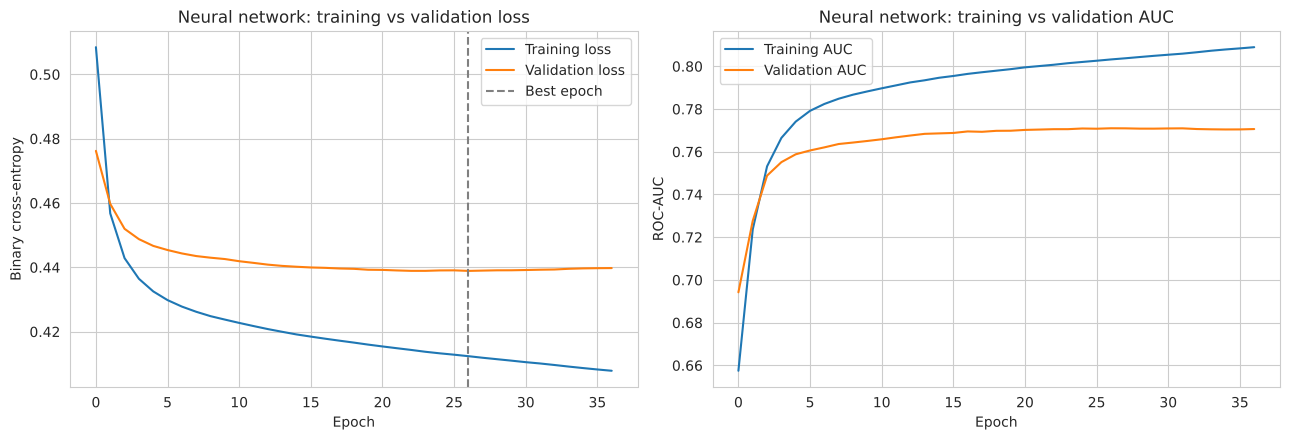

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history["loss"], label="Training loss")
axes[0].plot(history.history["val_loss"], label="Validation loss")
axes[0].axvline(best_epoch - 1, color="grey", linestyle="--", label="Best epoch")
axes[0].set_title("Neural network: training vs validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].plot(history.history["auc"], label="Training AUC")
axes[1].plot(history.history["val_auc"], label="Validation AUC")
axes[1].set_title("Neural network: training vs validation AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()
plt.tight_layout()
plt.show()

In [37]:
# Probabilities for validation and test sets
nn_val_prob  = nn_model.predict(X_nn_val_arr, verbose=0).ravel()
nn_test_prob = nn_model.predict(X_nn_test_arr, verbose=0).ravel()

# Threshold chosen on the validation set (never on the test set)
nn_threshold = choose_threshold(y_nn_val, nn_val_prob)
print("Neural network F1-optimal threshold (validation set):", round(float(nn_threshold), 3))

test_probs["Neural Network"] = nn_test_prob
best_threshold["Neural Network"] = nn_threshold
results_default.append(evaluate_model("Neural Network", y_test, nn_test_prob, 0.5))
results_tuned_thr.append(evaluate_model("Neural Network", y_test, nn_test_prob, nn_threshold))

print("\nNeural network on the test set:")
display(pd.DataFrame([results_default[-1], results_tuned_thr[-1]]).assign(
    Operating_point=["threshold 0.5", "validation-chosen threshold"]).set_index("Operating_point").drop(columns="Model").round(4))

print("Validation-set ROC-AUC:", round(roc_auc_score(y_nn_val, nn_val_prob), 4),
      "| validation-set average precision:", round(average_precision_score(y_nn_val, nn_val_prob), 4))

Neural network F1-optimal threshold (validation set): 0.287

Neural network on the test set:


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Operating_point,,,,,,,,
threshold 0.5,0.500,0.8188,0.6550,0.3821,0.4826,0.7693,0.5429,0.1368
validation-chosen threshold,0.287,0.7768,0.4961,0.5690,0.5300,0.7693,0.5429,0.1368


Validation-set ROC-AUC: 0.771 | validation-set average precision: 0.5268


**Interpretation.**
- **Training behaviour.** Training stopped after 37 epochs because validation loss did not improve for 10 epochs; the weights from epoch 27 (validation loss 0.4389) were restored. In the plots, training loss keeps falling while validation loss flattens and then rises slightly after about epoch 27, and training AUC (about 0.81) ends above validation AUC (about 0.77). This is the beginning of overfitting, and early stopping prevents the network from going further.
- **Test performance.** ROC-AUC 0.7693, average precision 0.5429 and Brier 0.1368. At the threshold chosen on the validation set (0.287) the precision is 0.496, recall 0.569 and F1 0.530.
- **Comparison.** The network is **comparable to the tree ensembles but not better**: its average precision (0.543) and AUC (0.769) are slightly below Gradient Boosting (0.555, 0.778). It beats Logistic Regression and the Decision Tree on these metrics. The network also trained on only 80% of the training data. As Section 12 shows, the gap to the tree ensembles is within sampling noise. Exact neural-network numbers can change a little between machines and TensorFlow versions even with a fixed seed.

---
## Section 12: Final Model Comparison

All baseline, tuned and neural-network models are placed in one table, at (a) the standard 0.5 threshold and (b) the threshold chosen from training-side data.

In [38]:
final_default = pd.DataFrame(results_default).set_index("Model")
final_thr = pd.DataFrame(results_tuned_thr).set_index("Model")

print("(a) All models at the default 0.5 threshold - test set")
display(final_default.sort_values("Avg Precision", ascending=False).round(4))

print("(b) All models at the training-chosen F1-optimal threshold - test set")
display(final_thr.sort_values("Avg Precision", ascending=False).round(4))

(a) All models at the default 0.5 threshold - test set


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Model,,,,,,,,
Gradient Boosting,0.5,0.8175,0.6611,0.3587,0.4651,0.7782,0.5554,0.1354
Gradient Boosting (tuned),0.5,0.8193,0.6723,0.3572,0.4665,0.7777,0.5549,0.1355
Random Forest (tuned),0.5,0.8172,0.6657,0.3482,0.4572,0.7742,0.5540,0.1355
Random Forest,0.5,0.8168,0.6583,0.3572,0.4631,0.7716,0.5526,0.1358
Neural Network,0.5,0.8188,0.6550,0.3821,0.4826,0.7693,0.5429,0.1368
Decision Tree,0.5,0.8172,0.6624,0.3534,0.4609,0.7417,0.4970,0.1396
Logistic Regression,0.5,0.8090,0.6946,0.2434,0.3605,0.7066,0.4911,0.1469


(b) All models at the training-chosen F1-optimal threshold - test set


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Brier
Model,,,,,,,,
Gradient Boosting,0.255,0.7820,0.5064,0.5682,0.5355,0.7782,0.5554,0.1354
Gradient Boosting (tuned),0.240,0.7770,0.4965,0.5855,0.5373,0.7777,0.5549,0.1355
Random Forest (tuned),0.245,0.7845,0.5112,0.5825,0.5446,0.7742,0.5540,0.1355
Random Forest,0.293,0.7893,0.5223,0.5569,0.5390,0.7716,0.5526,0.1358
Neural Network,0.287,0.7768,0.4961,0.5690,0.5300,0.7693,0.5429,0.1368
Decision Tree,0.298,0.8003,0.5566,0.4778,0.5142,0.7417,0.4970,0.1396
Logistic Regression,0.277,0.7863,0.5183,0.4808,0.4988,0.7066,0.4911,0.1469


### Is the difference between models real or just noise?
The test set has only a limited number of defaulters, so small gaps between models can be luck. As a simple check I **bootstrap** the test set: I resample the test customers with replacement 200 times and recompute average precision for each model. The 2.5th and 97.5th percentiles give a rough 95% interval. (This is a robustness check only; it does not change any model.)

In [39]:
rng = np.random.default_rng(RANDOM_STATE)
y_test_arr = y_test.values
n_test = len(y_test_arr)

boot_ap = {name: [] for name in test_probs}
for _ in range(200):
    idx = rng.integers(0, n_test, n_test)
    for name in test_probs:
        boot_ap[name].append(average_precision_score(y_test_arr[idx], test_probs[name][idx]))

ap_interval = pd.DataFrame({
    "Avg Precision": final_thr["Avg Precision"],
    "95% interval low": {n: np.percentile(v, 2.5) for n, v in boot_ap.items()},
    "95% interval high": {n: np.percentile(v, 97.5) for n, v in boot_ap.items()},
}).sort_values("Avg Precision", ascending=False)
display(ap_interval.round(4))

,Avg Precision,95% interval low,95% interval high
Gradient Boosting,0.5554,0.5255,0.5898
Gradient Boosting (tuned),0.5549,0.5257,0.5863
Random Forest (tuned),0.5540,0.5236,0.5838
Random Forest,0.5526,0.5227,0.5826
Neural Network,0.5429,0.5134,0.5704
Decision Tree,0.4970,0.4707,0.5327
Logistic Regression,0.4911,0.4592,0.5220


In [40]:
# Training-side ranking used to choose the preferred classical model (no test data involved)
cv_ap = pd.Series({n: average_precision_score(y_train, oof_probs[n]) for n in oof_probs}).sort_values(ascending=False)
print("Out-of-fold average precision on the training set:")
display(cv_ap.round(4).to_frame("CV Avg Precision"))

preferred_model = cv_ap.index[0]
print("Preferred classical model by training-side average precision:", preferred_model)
print("Its test-set average precision:", round(final_thr.loc[preferred_model, "Avg Precision"], 4),
      "| neural network test average precision:", round(final_thr.loc["Neural Network", "Avg Precision"], 4))

Out-of-fold average precision on the training set:


,CV Avg Precision
Random Forest (tuned),0.5598
Gradient Boosting (tuned),0.5574
Random Forest,0.5569
Gradient Boosting,0.5525
Decision Tree,0.5341
Logistic Regression,0.5053


Preferred classical model by training-side average precision: Random Forest (tuned)
Its test-set average precision: 0.554 | neural network test average precision: 0.5429


**Interpretation and choice.**

*Objective:* rank customers by default risk and flag a manageable group with reasonable precision. That points to **average precision** as the main selection metric, with F1 and the Brier score as supporting checks.

*Result:* the preferred model, chosen by a rule fixed in advance (highest out-of-fold average precision on the **training** data), is the **tuned Random Forest** (0.5598). On the test set it has average precision 0.554, ROC-AUC 0.774, Brier 0.1355 and, at its training-chosen threshold of 0.245, precision 0.511, recall 0.583 and the highest F1 of any model (0.545).

*Honest reading of the evidence:*
- The four tree ensembles (tuned and untuned Random Forest and Gradient Boosting) have test average precision within 0.003 of each other, and their bootstrap intervals (roughly 0.52-0.59) overlap almost completely. **They are statistically indistinguishable in this experiment.** Gradient Boosting has marginally the highest test AUC, AP and Brier score. I keep the Random Forest because the rule was fixed before looking at the test set, not because the test set proves it is better.
- The neural network (AP 0.543) is also inside the same interval range, so I cannot claim the tree ensembles beat it; I can only say it did not beat them.
- Logistic Regression (AP 0.491) and the Decision Tree (0.497) are about 0.06 lower and also lower on ROC-AUC, Brier score and out-of-fold results. I treat this difference as real but modest.

*Why another choice could be right:* if explainability and regulatory transparency matter most, Logistic Regression could be preferred despite lower recall (0.48 vs 0.58 at the chosen thresholds). If missing a defaulter is far costlier than a false alarm, a lower threshold than 0.245 would be chosen, giving higher recall and lower precision. If the probabilities themselves are needed (for example for provisioning), calibration would have to be checked more fully than the Brier score here.

---
## Section 13: Feature Importance and Business Interpretation

### Method
For the preferred model I use **permutation importance** computed on the held-out data: one feature at a time is shuffled, which breaks its link with the target, and I measure how much the average precision drops. A large drop means the model relies on that feature. It works for any model and uses the original column names, because the whole Pipeline is evaluated. I use the test set here only to *describe* the final model, not to choose or change it.

Important cautions:
- **Predictive importance is not causal impact.** The model shows which variables help predict default, not what would happen if a customer's value were changed.
- Strongly correlated variables (for example the six bill amounts) share importance, so each looks less important than the group together.

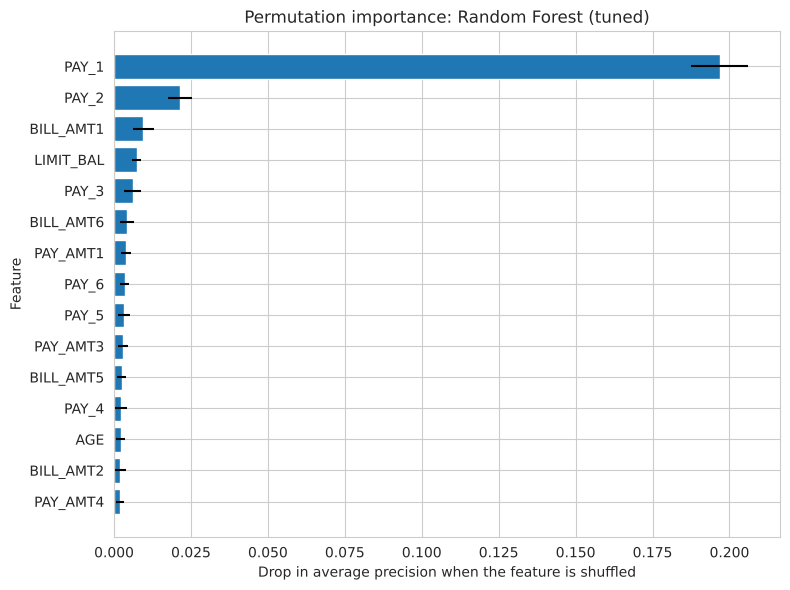

,Feature,Importance (drop in AP),Std
0,PAY_1,0.1968,0.0093
1,PAY_2,0.0213,0.0039
2,BILL_AMT1,0.0094,0.0034
3,LIMIT_BAL,0.0074,0.0015
4,PAY_3,0.0061,0.0027
5,BILL_AMT6,0.0042,0.0023
6,PAY_AMT1,0.0039,0.0016
7,PAY_6,0.0034,0.0015
8,PAY_5,0.0032,0.0021
9,PAY_AMT3,0.0029,0.0016


In [41]:
final_pipeline = pipelines[preferred_model]

perm = permutation_importance(final_pipeline, X_test, y_test, scoring="average_precision",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)

importance = pd.DataFrame({"Feature": X_test.columns,
                           "Importance (drop in AP)": perm.importances_mean,
                           "Std": perm.importances_std}).sort_values("Importance (drop in AP)", ascending=False)

top15 = importance.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top15["Feature"], top15["Importance (drop in AP)"], xerr=top15["Std"], color="tab:blue")
plt.title(f"Permutation importance: {preferred_model}")
plt.xlabel("Drop in average precision when the feature is shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance.head(10).round(4).reset_index(drop=True))

### Direction of the relationships: Logistic Regression coefficients
Permutation importance does not show whether a feature raises or lowers risk. Logistic Regression coefficients do (after scaling, a positive coefficient means a higher value of that feature goes with a higher predicted default probability, holding the other features fixed). Because many features are correlated, individual coefficients can be unstable, so they are used for **direction only**, with caution.

In [42]:
lr_pipe = pipelines["Logistic Regression"]
feature_names = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=feature_names)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print("Largest standardised coefficients (Logistic Regression):")
display(coefs.head(10).round(3).to_frame("coefficient"))

Largest standardised coefficients (Logistic Regression):


,coefficient
cat__EDUCATION_4,-1.121
num__PAY_1,0.663
num__BILL_AMT1,-0.324
num__PAY_AMT1,-0.200
num__PAY_AMT2,-0.178
cat__EDUCATION_3,-0.148
num__LIMIT_BAL,-0.121
num__BILL_AMT2,0.111
num__AGE,0.101
num__PAY_3,0.097


### Risk ranking of customers (decile table)
A practical way to use a probability model is to rank customers from highest to lowest predicted risk and check how many real defaulters fall in each group. I split the test customers into ten equal groups (decile 1 = highest predicted risk).

,customers,defaulters,default_rate,share of all defaulters,cumulative share of defaulters
decile,,,,,
1,600,414,0.690,0.312,0.312
2,600,262,0.437,0.197,0.509
3,600,161,0.268,0.121,0.631
4,600,95,0.158,0.072,0.702
5,600,110,0.183,0.083,0.785
6,600,79,0.132,0.060,0.845
7,600,79,0.132,0.060,0.904
8,600,51,0.085,0.038,0.943
9,600,46,0.077,0.035,0.977


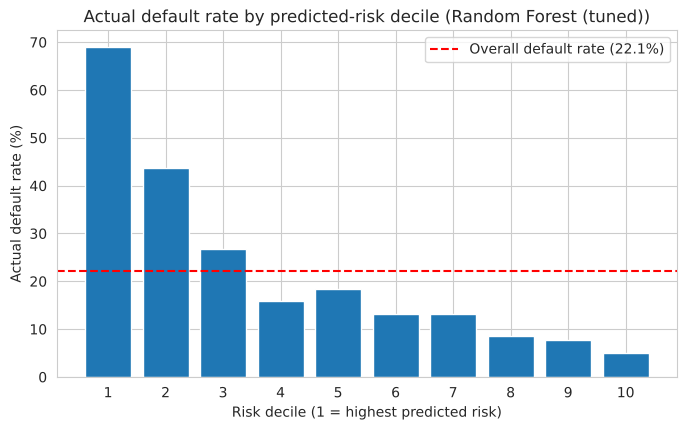

In [43]:
rank_df = pd.DataFrame({"prob": test_probs[preferred_model], "actual": y_test.values})
rank_df["decile"] = pd.qcut(rank_df["prob"].rank(method="first", ascending=False), 10, labels=range(1, 11))

decile_table = rank_df.groupby("decile", observed=True).agg(customers=("actual", "size"),
                                                           defaulters=("actual", "sum"),
                                                           default_rate=("actual", "mean"))
decile_table["share of all defaulters"] = decile_table["defaulters"] / decile_table["defaulters"].sum()
decile_table["cumulative share of defaulters"] = decile_table["share of all defaulters"].cumsum()
display(decile_table.round(3))

plt.figure(figsize=(8, 4.5))
plt.bar(decile_table.index.astype(str), decile_table["default_rate"] * 100)
plt.axhline(y_test.mean() * 100, color="red", linestyle="--", label=f"Overall default rate ({y_test.mean()*100:.1f}%)")
plt.title(f"Actual default rate by predicted-risk decile ({preferred_model})")
plt.xlabel("Risk decile (1 = highest predicted risk)")
plt.ylabel("Actual default rate (%)")
plt.legend()
plt.show()

**Interpretation.**
- **Repayment history dominates.** Shuffling `PAY_1` (September repayment status) lowers the model's average precision by about 0.197, roughly nine times more than the next feature (`PAY_2`, 0.021). Then come `BILL_AMT1` (0.009), `LIMIT_BAL` (0.007) and `PAY_3` (0.006). Other features each contribute very little; `AGE` ranks 13th and `EDUCATION` is not in the top 15. Because the bill columns are strongly correlated, their importance is split and each looks smaller than the group as a whole.
- **Direction (Logistic Regression, with caution).** `PAY_1` has a positive coefficient (+0.66): longer recent delay goes with higher predicted default risk. `LIMIT_BAL` (-0.12) and the payment amounts `PAY_AMT1` (-0.20) and `PAY_AMT2` (-0.18) are negative: higher limits and larger recent payments go with lower predicted risk. The coefficients of `BILL_AMT1` (-0.32) and `BILL_AMT2` (+0.11) have opposite signs, which is typical of strongly correlated variables and should not be read as separate effects. The very large `EDUCATION` "others" coefficient (-1.12) comes from a tiny group (468 customers, about 6-7% default) and from the dummy columns overlapping with the intercept, so it should not be over-interpreted.
- **Ranking power (decile table).** The 10% of test customers with the highest predicted risk have an actual default rate of 69.0% (against 22.1% overall) and contain 31.2% of all defaulters. The top 20% contain 50.9%, the top 30% contain 63.1% and the top 50% contain 78.5%. The lowest-risk decile has a 5.0% default rate. The decile rates are not perfectly smooth (decile 5 is 18.3% against 15.8% in decile 4), which is expected noise with 600 customers per decile.

**Predictive importance vs correlation vs causation.** *Correlation* describes how two variables move together. *Predictive importance* says how much a model relies on a variable to make accurate predictions. *Causal impact* would say what happens if the variable is changed. This analysis only supports the first two. A late payment in September does not "cause" a default in October. It is more likely an early symptom of the same financial stress. Credit limits were set by the bank using information not in this file.

**Cautious business insights.**
1. The most recent repayment behaviour is by far the most useful early-warning signal in this data, so monitoring accounts that have just become one or two months delinquent would be a natural focus for risk teams.
2. Credit limit and recent payment amounts add smaller but consistent information about who is more likely to default.
3. Demographic variables contributed little, and personal characteristics such as sex and marital status were deliberately kept out of the models.

---
## Section 14: Conclusion and Limitations

### What was analysed
30,000 credit-card customers from the UCI *Default of Credit Card Clients* dataset (22.1% defaulted next month). After removing the identifier, the target and the sensitive attributes `SEX` and `MARRIAGE`, 21 features were used.

### Approaches compared
A leakage-free workflow (stratified 80/20 split, preprocessing inside scikit-learn pipelines, 5-fold stratified cross-validation, thresholds chosen on training data) was used to compare Logistic Regression, Decision Tree, Random Forest and Gradient Boosting; tuned versions of Random Forest and Gradient Boosting; and a feed-forward neural network built with Keras.

### Observed results (single held-out test set of 6,000 customers)
- ROC-AUC ranged from 0.707 (Logistic Regression) to 0.778 (Gradient Boosting); average precision from 0.491 to 0.555.
- The four tree ensembles were practically tied (average precision 0.553 to 0.555), and the neural network was slightly lower (0.543) but within the same uncertainty range. Logistic Regression and the shallow Decision Tree were about 0.06 lower.
- The preferred model, the tuned Random Forest, reached ROC-AUC 0.774 and F1 0.545 (precision 0.511, recall 0.583) at a threshold of 0.245. Its top-risk decile had a 69% default rate against 22% overall.
- Hyperparameter tuning and the neural network did **not** noticeably improve on well-configured tree ensembles, which suggests the limit comes mainly from the information in the data.

### Most informative variables
Recent repayment status (`PAY_1`, by a wide margin), followed by `PAY_2`, the latest bill amount, the credit limit and `PAY_3`. This is predictive importance only, not proof of cause.

### Principal limitations
Detailed above: one dataset from one market and period, a one-month default label, no rejected applicants, undocumented codes, a threshold that ignores real costs, and one data split. At the chosen threshold roughly half of the flagged customers are false alarms, so the model is more useful for *ranking and prioritising* than for automatic decisions.

### Limitations
- **Single dataset, single period, single market** (Taiwan, 2005). Performance on other portfolios or time periods is unknown.
- **Short horizon label:** default is defined for one month only; this is not a measure of expected loss, and the dataset has no loss amount, exposure at default or recovery information.
- **Selection bias:** only approved customers are observed, so the models say nothing about rejected applicants.
- **Undocumented codes** (`PAY_` values -2 and 0; some `EDUCATION` and `MARRIAGE` codes) make part of the feature meaning uncertain.
- **Threshold and costs:** the thresholds here maximise F1, which treats false positives and false negatives as equally costly. A real lender would choose the threshold using actual costs and capacity.
- **Single train/test split** and one random seed: results will vary a little with a different split, and the bootstrap interval in Section 12 shows that small differences between models are not reliable.
- **Interpretation:** feature importance and coefficients describe associations in this data, **not causes**.

### What would be required before any real lending use
This is an **academic portfolio project and not a validated lending decision system**. Real use would require, at minimum: validation on out-of-time and out-of-sample data, calibration checks, ongoing monitoring for drift, a **fairness and bias assessment** (including proxies for protected attributes), explainability suitable for regulators and customers, model-risk governance and documentation, and legal and compliance review.

### Potential applications in risk analytics (for the future app phase)
Ranking customers by predicted risk for early-warning monitoring, prioritising collections, and comparing portfolio segments. These would be decision-*support* uses, with humans making the final calls.

---
## Section 15: References

1. Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473-2480.
2. UCI Machine Learning Repository: *Default of Credit Card Clients* dataset. https://archive.ics.uci.edu/dataset/350/default%2Bof%2Bcredit%2Bcard%2Bclients
3. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://scikit-learn.org
4. Abadi, M. et al. (2015). *TensorFlow: Large-scale machine learning on heterogeneous systems.* https://www.tensorflow.org ; Keras documentation: https://keras.io
5. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations (ICLR).* arXiv:1412.6980.
6. Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLoS ONE, 10*(3), e0118432.
7. Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32.
8. Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *Annals of Statistics, 29*(5), 1189-1232.